<a id="top"></a>
# Chapter 7 — Corrections: resolution, Q-damping and nano-size

**Reverse Monte Carlo with RMCProfile — from the pair distribution function to a refined box** · chapter 7 of 10

[◀ 6 Constraints, restraints and potentials](RMCProfile_06_Constraints_and_Potentials.ipynb) · [Contents of the book](README.md) · [8 Magnetic, EXAFS and diffuse scattering ▶](RMCProfile_08_Magnetic_EXAFS_Diffuse.ipynb)

**In this chapter**

- [§28 What the instrument does to G(r)](#sec-28)
- [§29 Damping: `RESOLUTION_CORRECTION` — measured, not assumed](#sec-29)
- [§30 Broadening: `BROADENING_CORRECTION`](#sec-30)
- [§31 Nano-size: what `PARTICLE_RADIUS` actually changes](#sec-31)

All chapters: [0](RMCProfile_00_Introduction.ipynb) · [1](RMCProfile_01_Total_Scattering_and_the_PDF.ipynb) · [2](RMCProfile_02_The_RMC_Algorithm.ipynb) · [3](RMCProfile_03_Starting_Configurations.ipynb) · [4](RMCProfile_04_Fitting_Neutron_Data.ipynb) · [5](RMCProfile_05_Xray_and_Bragg.ipynb) · [6](RMCProfile_06_Constraints_and_Potentials.ipynb) · [7](RMCProfile_07_Corrections.ipynb) · [8](RMCProfile_08_Magnetic_EXAFS_Diffuse.ipynb) · [9](RMCProfile_09_Analysing_Configurations.ipynb) · [10](RMCProfile_10_Benchmarks_and_Ecosystem.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them. Section numbers (§1–40), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import sys
import time
import tempfile
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# the toolkit lives in scripts/ at the repository root (chapters/ is one level down);
# build/execute.py --outdir runs a copy elsewhere and names the root in RMCPROFILE_SKILL_ROOT
for _cand in ("scripts", os.path.join("..", "scripts"),
              os.path.join(os.environ.get("RMCPROFILE_SKILL_ROOT", ""), "scripts")):
    if os.path.isfile(os.path.join(_cand, "rmcprofile_tools.py")):
        sys.path.insert(0, os.path.abspath(_cand))
        break
import rmcprofile_tools as rt
import rmclite as rl
import upstream_adapter as ua

plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (7.0, 4.0), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
warnings.filterwarnings("ignore", category=RuntimeWarning)

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 16}               # figure numbers run through the whole book
PKG = rt.find_package()                     # the user's RMCProfile package, or None
WORK = tempfile.mkdtemp(prefix="rmcbook-")  # scratch directory for the runs of this chapter

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def skip_without_package(what="this cell"):
    '''True (and a [SKIP] line) when RMCProfile is not installed; the cell then does nothing.'''
    if PKG is None:
        print(f"[SKIP] {what} — set RMCPROFILE_HOME to your RMCProfile_package directory")
        return True
    return False

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def show(fig):
    '''Display a figure and close it (keeps the notebook small).'''
    plt.show()
    plt.close(fig)

print("rmcprofile-skill", rt.__version__, "| numpy", np.__version__, "| RMCProfile package:",
      (PKG.platform + " build") if PKG else "not set", "| chapter 7")
t_chapter_start = time.time()

rmcprofile-skill 0.3.0 | numpy 2.5.2 | RMCProfile package: windows build | chapter 7


<a id="sec-28"></a>

## 28. What the instrument does to G(r)

A measured $F(Q)$ ends at a finite $Q_{\max}$ and is smeared by the instrument's resolution;
its Fourier transform $G(r)$ is therefore damped at large $r$ and its peaks broadened.
RMCProfile corrects the *calculated* function so that it can be compared with the data as
measured (manual §4.1, App. F): `RESOLUTION_CORRECTION` damps the calculated real-space
function, `BROADENING_CORRECTION` convolves it with a Gaussian whose width grows with $r$,
`R_CUTOFF` zeroes the Fourier ripples below the closest approach, and `PARTICLE_RADIUS`
applies a nanoparticle shape function. As in chapter 4 the data are synthetic, so the right
correction is known and the wrong one measurable — and everything runs at `TIME_LIMIT 0`,
which makes every comparison deterministic: one evaluation of the *truth box itself*
against the data, no moves, so the only thing that can differ is the correction.

In [2]:
NACL = [("Na", 0, 0, 0), ("Na", .5, .5, 0), ("Na", .5, 0, .5), ("Na", 0, .5, .5),
        ("Cl", .5, 0, 0), ("Cl", 0, .5, 0), ("Cl", 0, 0, .5), ("Cl", .5, .5, .5)]
A = 5.64
cfg = rt.build_configuration((A, A, A, 90, 90, 90), NACL, (3, 3, 3), title="NaCl 3x3x3")
rng = np.random.default_rng(0)
truth = rl.Box.from_rmc6f(cfg)
truth.frac = (truth.frac + rng.normal(0, 0.05, truth.frac.shape) / cfg.cell[0]) % 1.0
r, g_truth, G_truth = rl.synth_targets(truth, rmax=8.0, dr=0.02, noise=0.0, rng=rng)
G0 = -sum(c * rt.NEUTRON_B[t] for t, c in zip(cfg.atom_types, np.array(cfg.counts) / cfg.n_atoms())) ** 2 * rt.BARN_PER_FM2
print(f"G(r -> 0) = -(sum c b)^2 = {G0:.4f} barn")

model = truth.to_rmc6f(cfg)          # the model is the truth box itself: only the correction differs from the data

def evaluate(tag, G_data, block_items=(), scalars=()):
    '''One RMCProfile pass (TIME_LIMIT 0) of the truth box against G_data; returns (chi2, r, calc, expt).'''
    work = os.path.join(WORK, tag)
    rt.write_input_set("k", work, model, gr=(r, G_data), min_dist={"Na-Na": 3.0, "Na-Cl": 2.2, "Cl-Cl": 3.0},
                       max_move=0.05, time_limit_min=0.0, title=tag)
    d = rt.read_dat(os.path.join(work, "k.dat"))
    for k, v in block_items:
        d.set("NEUTRON_REAL_SPACE_DATA", k, v)
    for k, v in scalars:
        d.scalars[k] = v
        d.order.append(("scalar", k))
    d.write(os.path.join(work, "k.dat"))
    res = rt.run_rmcprofile("k", work, PKG, timeout_min=3)
    if res.returncode != 0 or not res.final_chi2:
        raise RuntimeError(f"{tag}: rc={res.returncode}; see {res.log_path}")
    x, calc, expt = rt.read_csv_pair(os.path.join(work, "k_PDF1.csv"))
    chi = res.final_chi2["Expt_1"]
    print(f"{tag:14s}: Expt_1 chi2 = {chi:.4g}")
    return chi, x, calc, expt

print("synthetic thermal G(r) ready;", "package found" if PKG else "no package")

G(r -> 0) = -(sum c b)^2 = -0.4361 barn
synthetic thermal G(r) ready; package found


<a id="sec-29"></a>

## 29. Damping: `RESOLUTION_CORRECTION` — measured, not assumed

The manual describes the keyword's value as "the exponent accounting for the dampening in
real-space … in the form of exp(−r∗Expo)". Before trusting a formula, measure it: evaluate
the same ideal lattice against the same data with and without the keyword and divide the
two calculated columns. The ratio below is not $e^{-\alpha r}$; it is the Gaussian
$e^{-(\alpha r)^2/2}$ — the form PDFgui calls `Qdamp`. This is the book's finding P-17:
the program is consistent, the manual's formula is not the one it applies.

ref           : Expt_1 chi2 = 1.278e-09


damp_measure  : Expt_1 chi2 = 29.01
max |ratio - exp(-a r)| = 0.288;  max |ratio - exp(-(a r)^2/2)| = 5.3e-15


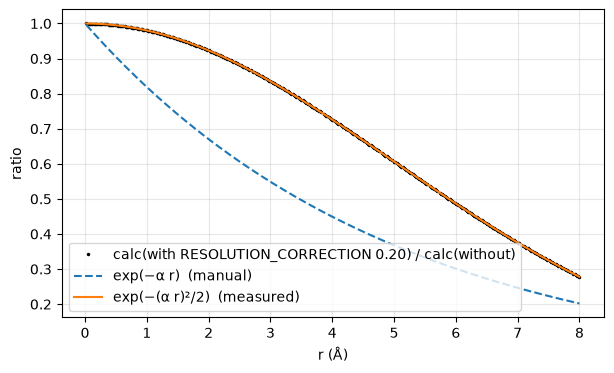

[PASS] the measured damping is Gaussian, exp(−(α r)²/2), to 1e-3 — 5.3e-15
[PASS] and it is not exp(−α r) — 0.288


In [3]:
if not skip_without_package("the damping measurement"):
    chi_ref, x, calc_ref, _ = evaluate("ref", G_truth)
    chi_a, _, calc_a, _ = evaluate("damp_measure", G_truth, [("RESOLUTION_CORRECTION", "0.20")])
    alpha_probe = 0.20
    ok = np.abs(calc_ref) > 0.05                    # avoid the zero crossings
    ratio = calc_a[ok] / calc_ref[ok]
    dev_exp = np.max(np.abs(ratio - np.exp(-alpha_probe * x[ok])))
    dev_gauss = np.max(np.abs(ratio - np.exp(-0.5 * (alpha_probe * x[ok]) ** 2)))
    print(f"max |ratio - exp(-a r)| = {dev_exp:.3f};  max |ratio - exp(-(a r)^2/2)| = {dev_gauss:.1e}")
    fig, ax = plt.subplots()
    ax.plot(x[ok], ratio, "k.", ms=3, label="calc(with RESOLUTION_CORRECTION 0.20) / calc(without)")
    ax.plot(x, np.exp(-alpha_probe * x), "--", label="exp(−α r)  (manual)")
    ax.plot(x, np.exp(-0.5 * (alpha_probe * x) ** 2), label="exp(−(α r)²/2)  (measured)")
    ax.set_xlabel("r (Å)"); ax.set_ylabel("ratio"); ax.legend()
    show(fig)
    caption("The damping RMCProfile applies for RESOLUTION_CORRECTION 0.20, measured as the "
            "ratio of two calculated G(r) columns of the same box: a Gaussian in r, not the "
            "exponential the manual writes.")
    check("the measured damping is Gaussian, exp(−(α r)²/2), to 1e-3", dev_gauss < 1e-3, f"{dev_gauss:.1e}")
    check("and it is not exp(−α r)", dev_exp > 0.1, f"{dev_exp:.3f}")

With the form known, synthesise "measured" data from the thermal box's $G(r)$ damped by
$e^{-(\alpha r)^2/2}$ with $\alpha = 0.05$ Å⁻¹, and evaluate the truth box against
them with no correction, with the right $\alpha$, and with a wrong one. The χ² of the data
set is lowest for the right correction.

damp_none     : Expt_1 chi2 = 0.2272


damp_right    : Expt_1 chi2 = 1.237e-09


damp_wrong    : Expt_1 chi2 = 24.14


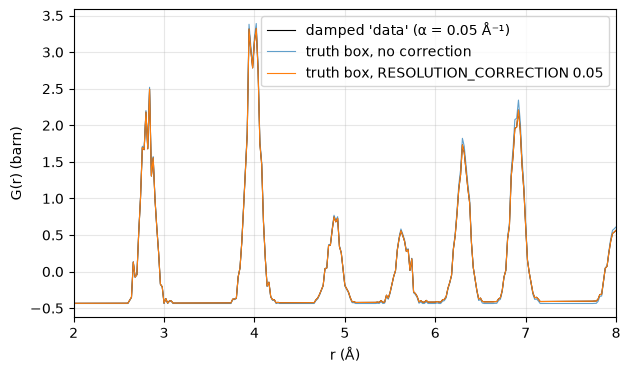

[PASS] the right damping gives the lowest chi2 of the three — none 0.2272, right 1.237e-09, wrong 24.14


In [4]:
alpha = 0.05
G_damped = G_truth * np.exp(-0.5 * (alpha * r) ** 2)
if not skip_without_package("the damping comparison"):
    chi_none, x, calc_none, expt = evaluate("damp_none", G_damped)
    chi_right, _, calc_right, _ = evaluate("damp_right", G_damped, [("RESOLUTION_CORRECTION", "0.05")])
    chi_wrong, _, calc_wrong, _ = evaluate("damp_wrong", G_damped, [("RESOLUTION_CORRECTION", "0.20")])
    fig, ax = plt.subplots()
    ax.plot(x, expt, "k", lw=0.8, label="damped 'data' (α = 0.05 Å⁻¹)")
    ax.plot(x, calc_none, lw=0.8, alpha=0.7, label="truth box, no correction")
    ax.plot(x, calc_right, lw=0.8, label="truth box, RESOLUTION_CORRECTION 0.05")
    ax.set_xlim(2, 8); ax.set_xlabel("r (Å)"); ax.set_ylabel("G(r) (barn)"); ax.legend()
    show(fig)
    caption("Synthetic G(r) damped by exp(−(0.05 r)²/2) against RMCProfile's calculated G(r) "
            "of the truth box without and with the matching RESOLUTION_CORRECTION: the "
            "corrected model's peaks shrink with r the way the data's do.")
    check("the right damping gives the lowest chi2 of the three", chi_right < chi_none and chi_right < chi_wrong,
          f"none {chi_none:.4g}, right {chi_right:.4g}, wrong {chi_wrong:.4g}")

<a id="sec-30"></a>

## 30. Broadening: `BROADENING_CORRECTION`

Finite resolution in $Q$ also broadens each peak in $r$ by an amount growing with $r$:
RMCProfile convolves its calculated function with a Gaussian of $\sigma = \beta r$ (App. F,
eq. F.1; the parameter is not PDFgui's `Qbroad`, eq. F.2 relates them). Synthesise data
broadened that way — the toolkit does the $r$-dependent convolution explicitly — and the
matching $\beta$ again wins the χ² comparison.

broad_none    : Expt_1 chi2 = 37.69


broad_right   : Expt_1 chi2 = 0.02819


broad_wrong   : Expt_1 chi2 = 56.91


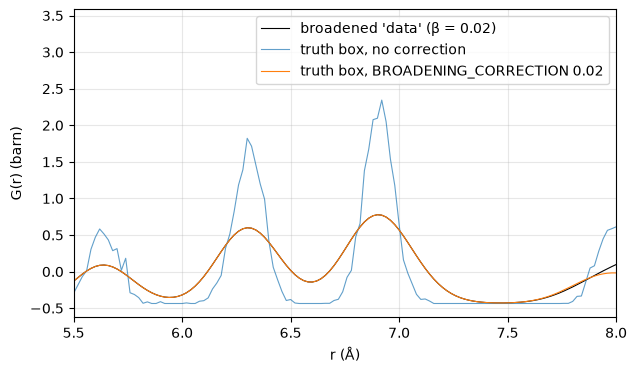

[PASS] the corrected column is broader than the uncorrected one at large r
[PASS] the right broadening gives the lowest chi2 of the three — none 37.69, right 0.02819, wrong 56.91


In [5]:
def broaden(G, r, beta):
    '''Convolve G(r) with a Gaussian whose width grows as beta*r (the r-dependent broadening of App. F).'''
    out = np.zeros_like(G)
    dr = r[1] - r[0]
    for k, rk in enumerate(r):
        s = max(beta * rk, dr)
        w = np.exp(-0.5 * ((r - rk) / s) ** 2)
        out[k] = np.sum(w * G) / np.sum(w)
    return out

beta = 0.02
G_broad = broaden(G_truth, r, beta)
if not skip_without_package("the broadening comparison"):
    chi_b_none, x, calc_b_none, expt_b = evaluate("broad_none", G_broad)
    chi_b_right, _, calc_b_right, _ = evaluate("broad_right", G_broad, [("BROADENING_CORRECTION", "0.02")])
    chi_b_wrong, _, calc_b_wrong, _ = evaluate("broad_wrong", G_broad, [("BROADENING_CORRECTION", "0.08")])
    fig, ax = plt.subplots()
    ax.plot(x, expt_b, "k", lw=0.8, label="broadened 'data' (β = 0.02)")
    ax.plot(x, calc_b_none, lw=0.8, alpha=0.7, label="truth box, no correction")
    ax.plot(x, calc_b_right, lw=0.8, label="truth box, BROADENING_CORRECTION 0.02")
    ax.set_xlim(5.5, 8); ax.set_xlabel("r (Å)"); ax.set_ylabel("G(r) (barn)"); ax.legend()
    show(fig)
    caption("At large r the r-dependent broadening is visible: the uncorrected truth-box "
            "peaks are narrower, the corrected ones spread like the synthetic data's.")
    peak = (x > 7.6) & (x < 8.0)
    check("the corrected column is broader than the uncorrected one at large r",
          calc_b_right[peak].max() < calc_b_none[peak].max())
    check("the right broadening gives the lowest chi2 of the three", chi_b_right < chi_b_none and chi_b_right < chi_b_wrong,
          f"none {chi_b_none:.4g}, right {chi_b_right:.4g}, wrong {chi_b_wrong:.4g}")

<a id="sec-31"></a>

## 31. Nano-size: what `PARTICLE_RADIUS` actually changes

For a particle of diameter $D$ the fraction of pairs at distance $r$ that fit inside it is
the spherical shape function $f(r) = 1 - \tfrac32 (r/D) + \tfrac12 (r/D)^3$ (Guinier). A
finite particle also has no uniform surroundings, so in Keen's $G(r) = \sum c_i c_j b_i b_j
(g_{ij} - 1)$ the "−1" — the bulk baseline $G_0 = -(\sum c b)^2$ — is what a nanoparticle
lacks beyond its size. RMCProfile's `PARTICLE_RADIUS ::` (manual §4.1; it insists on a
`BULK_RHO ::`, the bulk number density, beside it — without that keyword the program stops
with "Low dimension RMC requested. But no 'BULK_RHO' keyword found", which the checker now
reports before the run, finding P-18) is documented with one line and a paper "to be
published". So measure it as in §29: the difference between the calculated columns of the
same box with and without the keyword. It is not a multiplication of the peaks by $f$; it
is $-G_0\,[1 - f(r)]$ — the bulk baseline replaced by the envelope-weighted one — beyond a
short-distance cutoff below which nothing changes (the `NANO_RCUTOFF_OFF` keyword's realm).

[PASS] the envelope is 1 at r = 0 and 0 at r = D
[PASS] at r = D/2 the envelope is 5/16


nano_R10      : Expt_1 chi2 = 8.433
R = 10 Å: rms of (difference − hypothesis) beyond 3.5 Å = 0.0094 barn; the difference is zero below 2.24 Å


nano_R5       : Expt_1 chi2 = 27.68
R = 5 Å: rms of (difference − hypothesis) beyond 3.5 Å = 0.0091 barn; the difference is zero below 1.78 Å


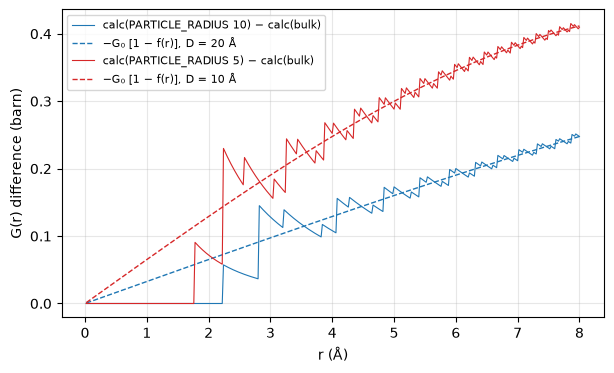

[PASS] beyond 3.5 Å the change is −G₀[1 − f(r)] with D = 2R to 0.02 barn for both radii — R=10: 0.0094, R=5: 0.0091


nano_none     : Expt_1 chi2 = 8.585


nano_right    : Expt_1 chi2 = 0.2869


nano_wrong    : Expt_1 chi2 = 5.743
[PASS] against data built with that rule the right radius gives the lowest chi2 — none 8.585, right 0.2869, wrong 5.743


In [6]:
def sphere_envelope(r, D):
    x = np.clip(r / D, 0, 1)
    return 1 - 1.5 * x + 0.5 * x ** 3

check("the envelope is 1 at r = 0 and 0 at r = D", sphere_envelope(np.array([0.0]), 20.0)[0] == 1.0 and sphere_envelope(np.array([20.0]), 20.0)[0] == 0.0)
check("at r = D/2 the envelope is 5/16", abs(sphere_envelope(np.array([10.0]), 20.0)[0] - 5 / 16) < 1e-12)
if not skip_without_package("the nano-size measurement"):
    fig, ax = plt.subplots()
    devs = {}
    for R, style in ((10.0, "C0"), (5.0, "C3")):
        _, x, calc_R, _ = evaluate(f"nano_R{R:.0f}", G_truth, scalars=[("PARTICLE_RADIUS", f"{R:.1f}"), ("BULK_RHO", f"{cfg.density:.6f}")])
        diff = calc_R - calc_ref
        hyp = -G0 * (1 - sphere_envelope(x, 2 * R))
        far = x > 3.5
        devs[R] = np.sqrt(np.mean((diff[far] - hyp[far]) ** 2))
        ax.plot(x, diff, style, lw=0.8, label=f"calc(PARTICLE_RADIUS {R:.0f}) − calc(bulk)")
        ax.plot(x, hyp, style + "--", lw=1.0, label=f"−G₀ [1 − f(r)], D = {2 * R:.0f} Å")
        print(f"R = {R:.0f} Å: rms of (difference − hypothesis) beyond 3.5 Å = {devs[R]:.4f} barn; the difference is zero below {x[np.argmax(np.abs(diff) > 1e-6)]:.2f} Å")
    ax.set_xlabel("r (Å)"); ax.set_ylabel("G(r) difference (barn)"); ax.legend(fontsize=8)
    show(fig)
    caption("What PARTICLE_RADIUS adds to RMCProfile's calculated G(r) of the same box for "
            "radii of 10 and 5 Å (solid), against the bulk baseline −G₀ multiplied by one "
            "minus the spherical shape function of a particle of diameter 2R (dashed): the "
            "keyword replaces the uniform background, not the peaks, and does nothing below "
            "the closest approach.")
    check("beyond 3.5 Å the change is −G₀[1 − f(r)] with D = 2R to 0.02 barn for both radii", all(v < 0.02 for v in devs.values()),
          ", ".join(f"R={R:.0f}: {v:.4f}" for R, v in devs.items()))

    # consistency: data built with the same rule, and the right radius wins the chi2 comparison
    D = 20.0
    G_nano = G_truth - G0 * (1 - sphere_envelope(r, D))
    chi_n_none = evaluate("nano_none", G_nano)[0]
    chi_n_right = evaluate("nano_right", G_nano, scalars=[("PARTICLE_RADIUS", f"{D / 2:.1f}"), ("BULK_RHO", f"{cfg.density:.6f}")])[0]
    chi_n_wrong = evaluate("nano_wrong", G_nano, scalars=[("PARTICLE_RADIUS", "5.0"), ("BULK_RHO", f"{cfg.density:.6f}")])[0]
    check("against data built with that rule the right radius gives the lowest chi2", chi_n_right < chi_n_none and chi_n_right < chi_n_wrong,
          f"none {chi_n_none:.4g}, right {chi_n_right:.4g}, wrong {chi_n_wrong:.4g}")

### Exercises for chapter 7

**7.1** Scan `RESOLUTION_CORRECTION` over 0.02, 0.05, 0.10 against the data of §29 and
plot χ² against α. Where is the minimum, and how sharp is it?

**7.2** Apply both damping (α = 0.05) and broadening (β = 0.02) to the synthetic data and
show that the two corrections together beat either alone.

**7.3** (no code) The measurement of §31 was made on a *bulk* box. Why is the baseline, and
not the peak height, what a nanoparticle configuration in a large box needs corrected? Think
about which pairs the box's own histogram already lacks.

In [7]:
if not skip_without_package("the exercises"):
    # 7.1
    alphas = [0.02, 0.05, 0.10]
    chis = [evaluate(f"scan_{a}", G_damped, [("RESOLUTION_CORRECTION", f"{a:.2f}")])[0] for a in alphas]
    print(dict(zip(alphas, np.round(chis, 4))))
    check("7.1 the chi2 minimum of the scan is at the true alpha = 0.05", alphas[int(np.argmin(chis))] == 0.05)
    # 7.2
    G_both = broaden(G_truth, r, beta) * np.exp(-0.5 * (alpha * r) ** 2)
    c_a = evaluate("both_alpha", G_both, [("RESOLUTION_CORRECTION", "0.05")])[0]
    c_b = evaluate("both_beta", G_both, [("BROADENING_CORRECTION", "0.02")])[0]
    c_ab = evaluate("both_ab", G_both, [("RESOLUTION_CORRECTION", "0.05"), ("BROADENING_CORRECTION", "0.02")])[0]
    check("7.2 both corrections together beat either alone", c_ab < c_a and c_ab < c_b, f"a {c_a:.4g}, b {c_b:.4g}, both {c_ab:.4g}")

scan_0.02     : Expt_1 chi2 = 0.159


scan_0.05     : Expt_1 chi2 = 1.237e-09


scan_0.1      : Expt_1 chi2 = 1.666
{0.02: np.float64(0.159), 0.05: np.float64(0.0), 0.1: np.float64(1.666)}
[PASS] 7.1 the chi2 minimum of the scan is at the true alpha = 0.05


both_alpha    : Expt_1 chi2 = 34.64


both_beta     : Expt_1 chi2 = 0.09587


both_ab       : Expt_1 chi2 = 0.02405
[PASS] 7.2 both corrections together beat either alone — a 34.64, b 0.09587, both 0.02405


In [8]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 7 — checks passed : {_CHECKS['pass']}")
print(f"chapter 7 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 7 — checks passed : 11
chapter 7 — checks failed : 0
wall time                 : 8 s
Every quantitative claim in this notebook was verified in this run.
